# data loading and libraries  

In [ ]:
!pip install lightgbm

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
import shap
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Download dataset (BRFSS diabetes dataset)
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Dataset path:", path)

100%|██████████| 6.03M/6.03M [00:06<00:00, 1.05MB/s]

Extracting files...
Dataset path: /home/seif_khashaba/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1


In [ ]:
df = pd.read_csv(path + "/diabetes_binary_health_indicators_BRFSS2015.csv")

# EDA & preprocessing  

In [ ]:

print("--- Dataset Information ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe().to_markdown(numalign="left", stralign="left"))

print("\n--- Missing Values ---")
print(df.isnull().sum().to_markdown(numalign="left", stralign="left"))

print("\n--- Target Variable Distribution (Diabetes_binary) ---")
print(df['Diabetes_binary'].value_counts().to_markdown(numalign="left", stralign="left"))
print(df['Diabetes_binary'].value_counts(normalize=True).to_markdown(numalign="left", stralign="left"))

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               25

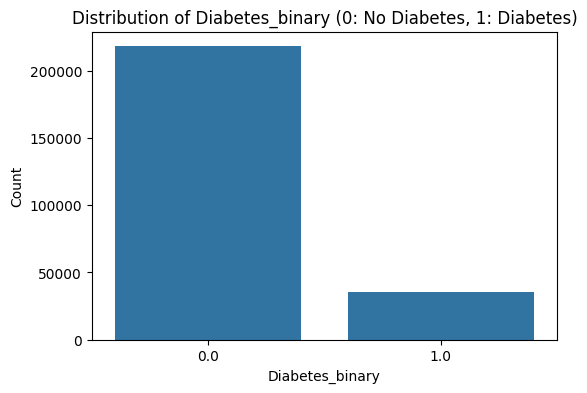


--- Initial Feature Distributions (Selected Features) ---


/tmp/ipykernel_2136/2845083950.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')


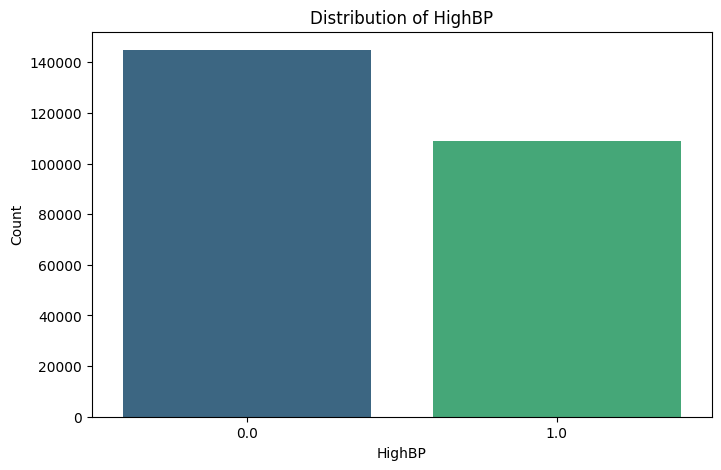

/tmp/ipykernel_2136/2845083950.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')


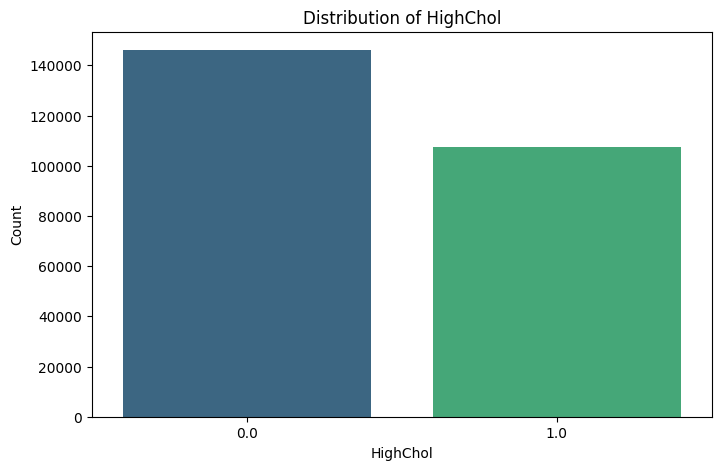

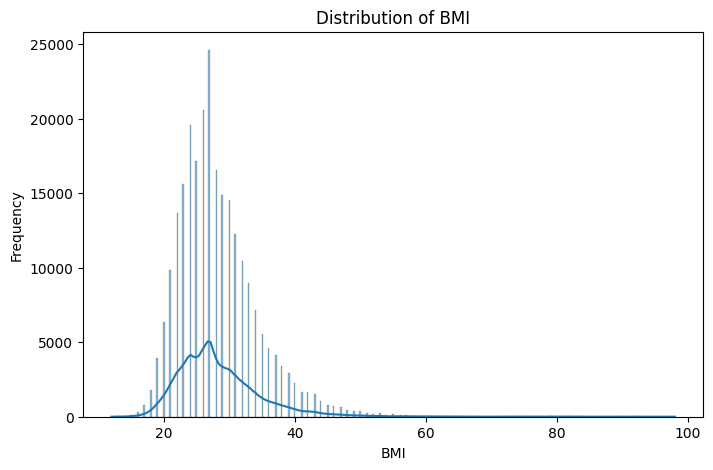

/tmp/ipykernel_2136/2845083950.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')


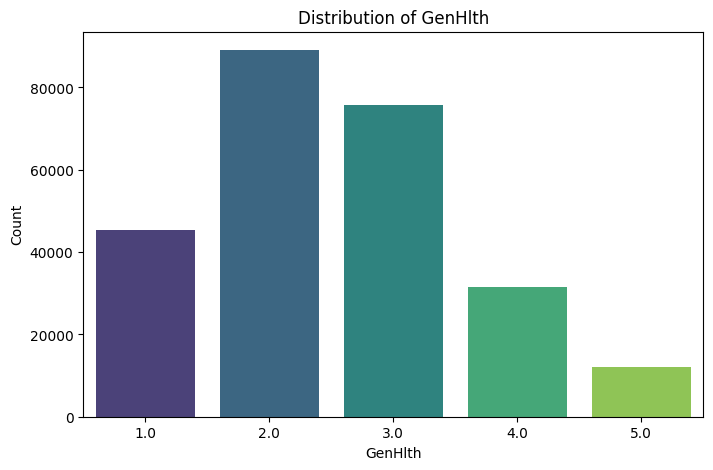

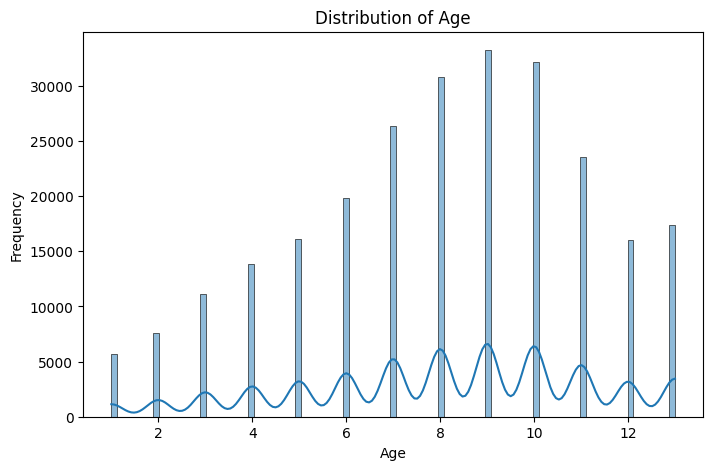

/tmp/ipykernel_2136/2845083950.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')


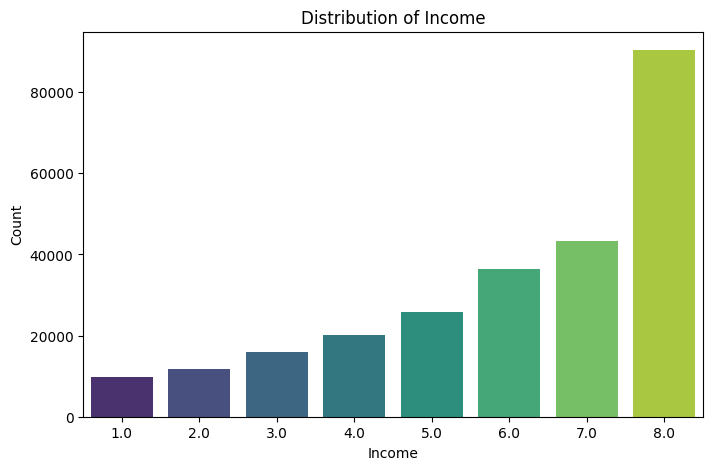

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Diabetes_binary', data=df)
plt.title('Distribution of Diabetes_binary (0: No Diabetes, 1: Diabetes)')
plt.xlabel('Diabetes_binary')
plt.ylabel('Count')
plt.show()

print("\n--- Initial Feature Distributions (Selected Features) ---")

# Select some representative features for visualization
features_to_plot = ['HighBP', 'HighChol', 'BMI', 'GenHlth', 'Age', 'Income']

for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    if df[feature].dtype == 'object' or df[feature].nunique() < 10:
        sns.countplot(x=feature, data=df, palette='viridis')
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Count')
    else:
        sns.histplot(df[feature], kde=True)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
    plt.show()


In [ ]:
y = df["Diabetes_binary"]
X = df.drop("Diabetes_binary", axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)